In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
file_path = "sp500_stocks.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "andrewmvd/sp-500-stocks",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
#Kiếm tra dữ liệu
print("First 5 records:", df.head())
print(df.info)

/tmp/ipython-input-2131242540.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sp-500-stocks' dataset.
First 5 records:          Date Symbol  Adj Close  Close  High  Low  Open  Volume
0  2010-01-04    MMM        NaN    NaN   NaN  NaN   NaN     NaN
1  2010-01-05    MMM        NaN    NaN   NaN  NaN   NaN     NaN
2  2010-01-06    MMM        NaN    NaN   NaN  NaN   NaN     NaN
3  2010-01-07    MMM        NaN    NaN   NaN  NaN   NaN     NaN
4  2010-01-08    MMM        NaN    NaN   NaN  NaN   NaN     NaN
<bound method DataFrame.info of                Date Symbol  Adj Close  Close  High  Low  Open  Volume
0        2010-01-04    MMM        NaN    NaN   NaN  NaN   NaN     NaN
1        2010-01-05    MMM        NaN    NaN   NaN  NaN   NaN     NaN
2        2010-01-06    MMM        NaN    NaN   NaN  NaN   NaN     NaN
3        2010-01-07    MMM        NaN    NaN   NaN  NaN   NaN     NaN
4        2010-01-08    MMM        NaN    NaN   NaN  NaN   NaN     NaN
...             ...    ...        ...    ...   ...  ...   ...     ...
1891531  

In [ ]:
#Kiểm tra dữ liệu thiếu
df.isna().sum()

,0
Date,0
Symbol,0
Adj Close,1273705
Close,1273705
High,1273705
Low,1273705
Open,1273705
Volume,1273705


In [ ]:
#Drop dữ liệu nan
df = df.dropna()
df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617831 entries, 3768 to 1876463
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       617831 non-null  object 
 1   Symbol     617831 non-null  object 
 2   Adj Close  617831 non-null  float64
 3   Close      617831 non-null  float64
 4   High       617831 non-null  float64
 5   Low        617831 non-null  float64
 6   Open       617831 non-null  float64
 7   Volume     617831 non-null  float64
dtypes: float64(6), object(2)
memory usage: 42.4+ MB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') #Chuyển kiểu dữ liệu Date: object --> datetime

In [ ]:
# 1. Chọn một mã cổ phiếu cụ thể để dự báo (Ví dụ: 'AAPL')
# Bạn có thể thay đổi ticker này tùy theo yêu cầu của nhóm
ticker = 'GOOG'
df_stock = df[df['Symbol'] == ticker].copy()

# 2. Xử lý định dạng ngày tháng và sắp xếp
df_stock['Date'] = pd.to_datetime(df_stock['Date'])
df_stock = df_stock.sort_values('Date')

# 3. Lấy cột 'Adj Close' (Giá đóng cửa điều chỉnh) - Đây là giá trị phản ánh chính xác nhất
data = df_stock.filter(['Adj Close'])
dataset = data.values

# 4. Chia tập dữ liệu (80% Train, 20% Test)
training_data_len = int(np.ceil(len(dataset) * 0.8))

# 5. Chuẩn hóa dữ liệu về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [ ]:
window_size = 60
train_data = scaled_data[0:int(training_data_len), :]

x_train, y_train = [], []

for i in range(window_size, len(train_data)):
  x_train.append(train_data[i-window_size:i, 0])
  y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape dữ liệu sang 3D [samples, time steps, features] cho LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [ ]:
model = Sequential([
  # Lớp LSTM 1
  LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
  Dropout(0.2), # Chống overfitting

  # Lớp LSTM 2
  LSTM(units=50, return_sequences=False),
  Dropout(0.2),

  # Lớp Dense (kết nối đầy đủ)
  Dense(units=25),
  Dense(units=1) # Đầu ra là 1 giá trị duy nhất
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
# Bạn có thể tăng epochs lên 20-50 để đạt độ chính xác cao hơn
model.fit(x_train, y_train, batch_size=32, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0100
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 5.8788e-04
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 5.2447e-04
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 4.4779e-04
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 4.3162e-04
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 3.6721e-04
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 3.2649e-04
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 3.3313e-04
Epoch 9/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 3.2682e-04
Epoch 10/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 3.0679e-04


In [ ]:
# Tạo tập dữ liệu Test
test_data = scaled_data[training_data_len - window_size:, :]
x_test = []
y_test = dataset[training_data_len:, :] # Giá thực tế để đối chiếu

for i in range(window_size, len(test_data)):
  x_test.append(test_data[i-window_size:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Dự báo giá
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions) # Đưa về giá trị USD thực tế

# Tính sai số RMSE
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
mape = np.mean(np.abs((y_test - predictions) / (y_test))) * 100
print(f"KẾT QUẢ ĐÁNH GIÁ ({ticker})")
print(f"{ticker} RMSE: {rmse:.2f} USD")
print(f"{ticker} MAPE: {mape:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
KẾT QUẢ ĐÁNH GIÁ (GOOG)
GOOG RMSE: 5.12 USD
GOOG MAPE: 3.14%


/tmp/ipython-input-1422524055.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid.loc[:, 'Predictions'] = predictions # Thêm cột dự báo vào df


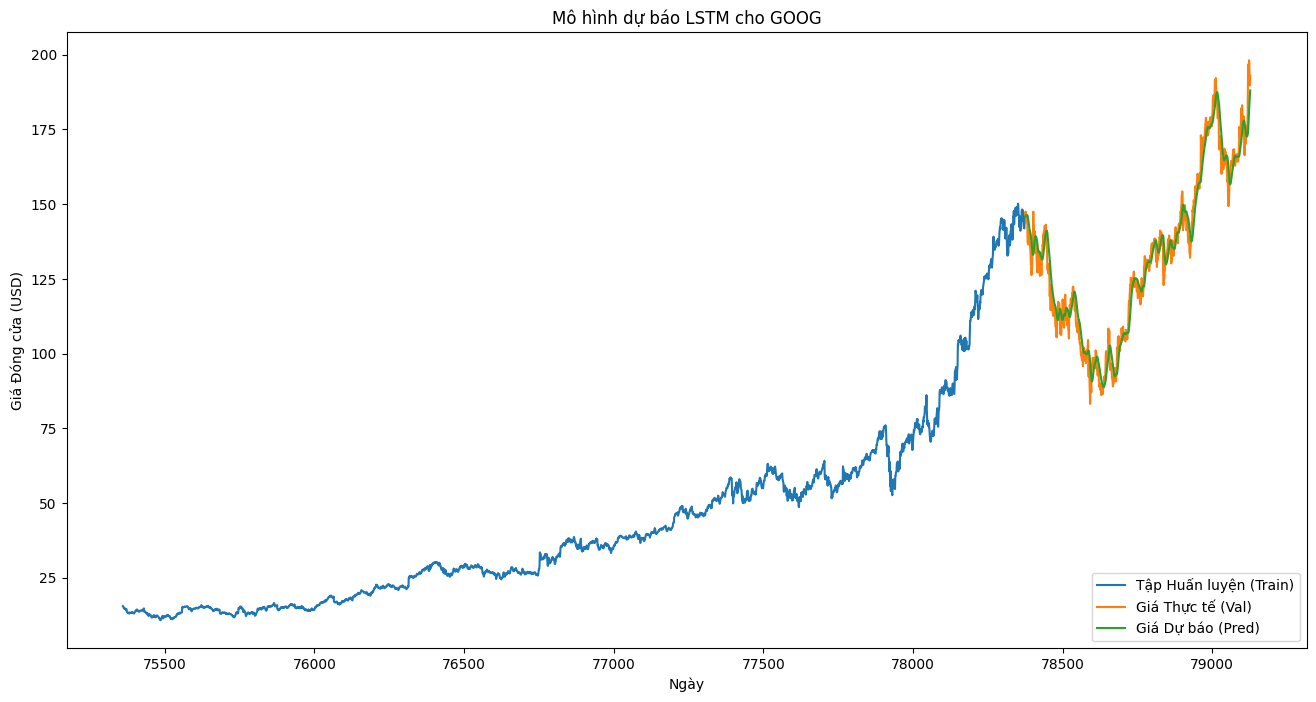

In [ ]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid.loc[:, 'Predictions'] = predictions # Thêm cột dự báo vào df

plt.figure(figsize=(16, 8))
plt.title(f'Mô hình dự báo LSTM cho {ticker}')
plt.xlabel('Ngày')
plt.ylabel('Giá Đóng cửa (USD)')
plt.plot(train['Adj Close'])
plt.plot(valid[['Adj Close', 'Predictions']])
plt.legend(['Tập Huấn luyện (Train)', 'Giá Thực tế (Val)', 'Giá Dự báo (Pred)'], loc='lower right')
plt.show()

In [ ]:
# 1. Làm sạch danh sách mã cổ phiếu
df['Symbol'] = df['Symbol'].str.strip()
all_tickers = df['Symbol'].unique()

# Danh sách lưu trữ điểm số của từng mã
list_rmse, list_mae, list_mape = [], [], []
window_size = 60

print(f"Đang bắt đầu chấm điểm mô hình trên danh mục...")

# Để demo, chúng ta thử nghiệm với 30 mã đầu tiên (Bạn có thể bỏ [:30] để chạy hết)
for ticker in all_tickers[:30]:
  try:
      # Lọc và kiểm tra dữ liệu
      ticker_df = df[df['Symbol'] == ticker].sort_values('Date')
      if len(ticker_df) < 200: continue # Bỏ qua nếu dữ liệu quá ít

      # Tiền xử lý
      data_values = ticker_df.filter(['Close']).values
      training_len = int(np.ceil(len(data_values) * 0.8))

      # Scaling
      scaler = MinMaxScaler(feature_range=(0, 1))
      scaled_data = scaler.fit_transform(data_values)

      # Tạo tập Test (dữ liệu mô hình chưa thấy)
      test_data = scaled_data[training_len - window_size:, :]
      x_test, y_actual = [], data_values[training_len:, :]

      for i in range(window_size, len(test_data)):
          x_test.append(test_data[i-window_size:i, 0])

      x_test = np.array(x_test)
      x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

      # DỰ BÁO
      predictions = model.predict(x_test, verbose=0)
      predictions = scaler.inverse_transform(predictions) # Đưa về giá USD

      # TÍNH ĐIỂM CHO MÃ NÀY
      list_rmse.append(np.sqrt(mean_squared_error(y_actual, predictions)))
      list_mae.append(mean_absolute_error(y_actual, predictions))
      list_mape.append(mean_absolute_percentage_error(y_actual, predictions))

  except Exception as e:
      continue

# 3. TỔNG KẾT ĐIỂM SỐ TỔNG THỂ
if list_mape:
    final_mape = np.mean(list_mape) * 100
    final_rmse = np.mean(list_rmse)

    print("\n" + "="*40)
    print(f"BÁO CÁO ĐIỂM SỐ MÔ HÌNH LSTM")
    print(f"Tổng số cổ phiếu đánh giá: {len(list_mape)}")
    print(f"RMSE ({len(list_rmse)} stocks): {final_rmse:.4f} USD")
    print(f"MAPE ({len(list_mape)} stocks): {final_mape:.2f}%")
    print("="*40)

    if final_mape < 5:
        print("Đánh giá: Mô hình cực kỳ chính xác (Excellent).")
    elif final_mape < 15:
        print("Đánh giá: Mô hình có độ chính xác tốt (Good).")
    else:
        print("Đánh giá: Mô hình cần được tối ưu thêm (Poor).")

Đang bắt đầu chấm điểm mô hình trên danh mục...
